In [1]:
from astropy.table import Table

tbl = Table.read("./catalog.fits")
tbl.sort("luminosity")
#tbl

In [2]:
from stacking import prepare_subcube, subtract_sky_per_slice, make_narrowband, subtract_continuum
import matplotlib.pyplot as plt
import numpy as np
import zarr

ra = 334.22799779075706
dec = 0.33472768057870866
z = 2.98473243149245	

cube = zarr.open("/Users/bene/Desktop/mpe/fits/cubes/cube.zarr", mode="r")

In [3]:
sub_cube, sub_wcs = prepare_subcube(ra, dec, z, cube, width=50, spec_width=25)

In [4]:
subtracted_cube = subtract_sky_per_slice(sub_cube)
contsub = subtract_continuum(subtracted_cube)

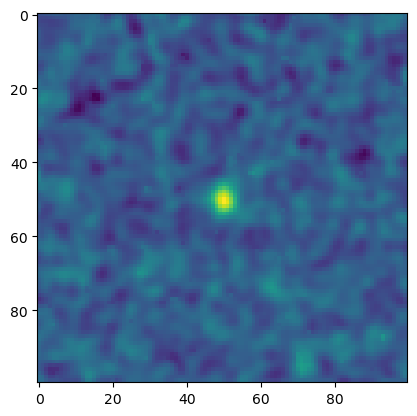

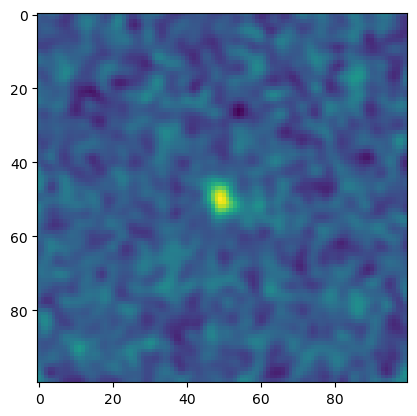

In [5]:
img = make_narrowband(contsub)
test = make_narrowband(sub_cube)
plt.imshow(img)
plt.show()
plt.imshow(test)
plt.show()

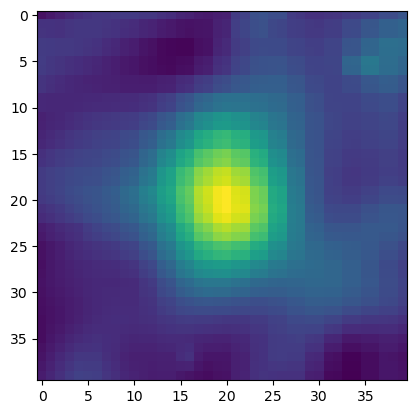

In [6]:
# Scaling
from stacking import scale_source


scaled, _ = scale_source(img, sub_wcs, ra, dec, z, 2, 40)
plt.imshow(scaled)

In [9]:
from stacking import Stacking

from astropy.table import Table

tbl = Table.read("./catalog.fits")
tbl.sort("luminosity")
tbl = tbl[:10]

from stacking import Stacking
import matplotlib.pyplot as plt
import numpy as np
import zarr	

cube = zarr.open("/Users/bene/Desktop/mpe/fits/cubes/cube.zarr", mode="r")

stack = Stacking(tbl, cube, kpc_pxl=3, npix=20)

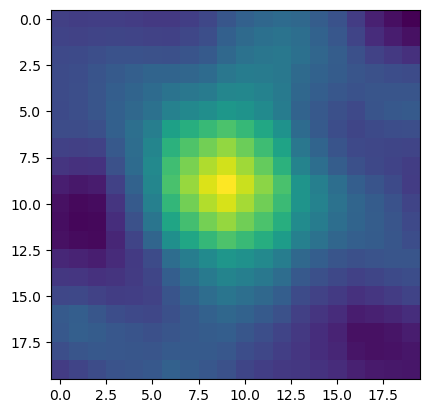

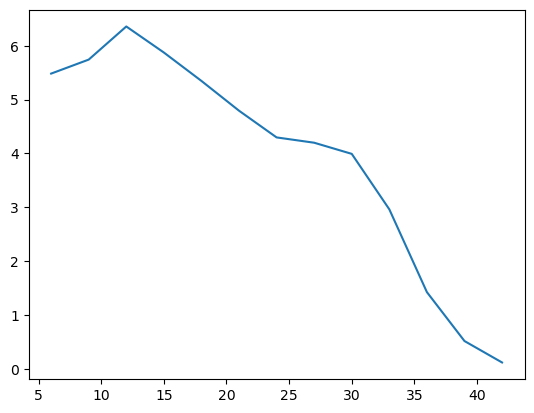

In [10]:
img = stack.stack()
radi, fluxes, _ = stack.cog(img, r_max=15)
plt.imshow(img)
plt.show()
plt.plot(radi, fluxes)
plt.show()